# Import ibrary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# inisialisasi  file csv

In [2]:
data = pd.read_excel('Data_AF.xlsx', index_col=0)
data.head()

,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
Kabupaten/Kota Se Jawa Timur,,,,,,,,,,,,,,,,,,,,,
Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# Check Missing Value

In [3]:
data.isnull().sum()

Tingkat Pengangguran Terbuka                                        0
Tingkat Partisipasi Angkatan Kerja                                  0
Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan           0
Jumlah Pelanggan Air Bersih                                         0
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan     0
Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal                   0
Jumlah Penduduk Bekerja 15 Tahun Keatas                             0
Jumlah Penduduk Sekolah 15 Tahun Keatas                             0
Distribusi Penduduk                                                 0
Persentase Perempuan Kawin di Bawah Umur                            0
Rasio Jenis Kelamin                                                 0
Angka Melek Huruf penduduk miskin 15-55tahun                        0
Ruta miskin yg menggunakan air layak                                0
Ruta miskin yg menggunakan jamban                                   0
Ruta miskin penerima

# Handling Missing Value

In [4]:
data.fillna(data.mean(numeric_only=True), inplace=True)
data.head()

,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
Kabupaten/Kota Se Jawa Timur,,,,,,,,,,,,,,,,,,,,,
Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# Menentukan Variabel

In [6]:
data[[
    'Indeks Keparahan Kemiskinan (P2) ',
    'Gini Rasio ',
    'Angka Kesakitan ',
    'PDRB Atas Dasar Harga Konstan 2010 ',
    'Tingkat Partisipasi Angkatan Kerja ',
    'Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan ',
    'Angka Melek Huruf penduduk miskin 15-55tahun',
    'Ruta miskin yg menggunakan air layak ',
    'Tingkat Pengangguran Terbuka ',
    'Persentase Perempuan Kawin di Bawah Umur ',
    'Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal ',
    'Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun ',
]]
data.head()

,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
Kabupaten/Kota Se Jawa Timur,,,,,,,,,,,,,,,,,,,,,
Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# Deteksi Outlier Z-Score

Outlier terdeteksi pada:
Jumlah outlier: 2


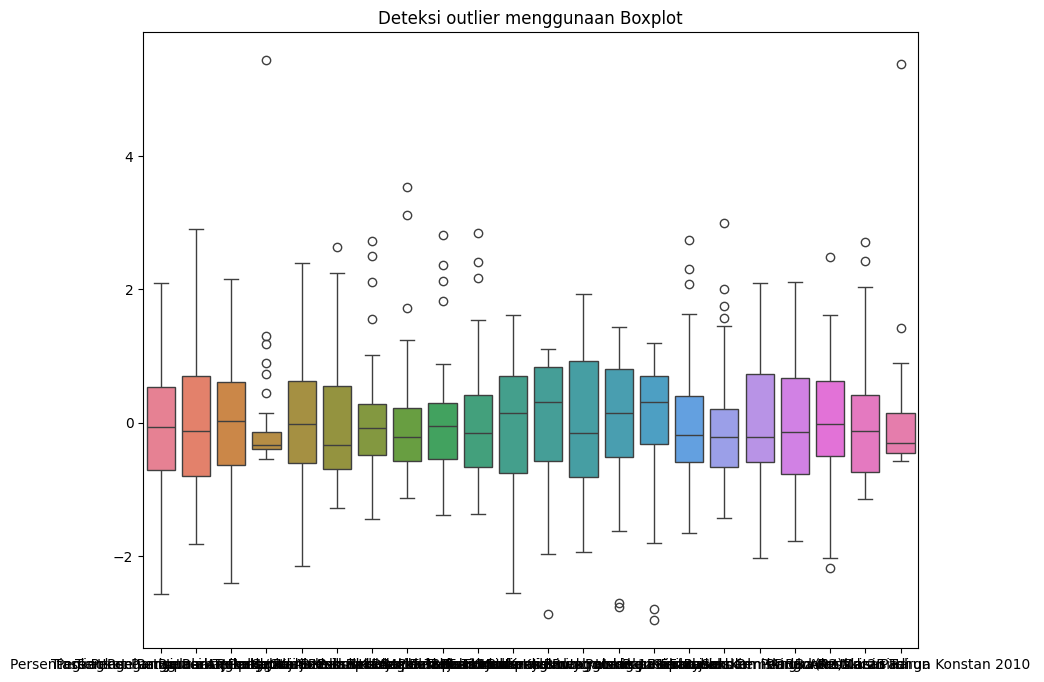

In [9]:
import numpy as np
from scipy import stats
scaler = StandardScaler()
df_scaled = scaler.fit_transform(data)
df_scaled = pd.DataFrame(df_scaled, columns=data.columns)

z_scores =  np.abs(stats.zscore(df_scaled))
outlier_mask = (z_scores > 3).any(axis=1)

print("Outlier terdeteksi pada:")
data.loc[outlier_mask]
print("Jumlah outlier:", len(data.loc[outlier_mask]))


plt.figure(figsize=(10, 8))
sns.boxplot(data=df_scaled)
plt.title("Deteksi outlier menggunaan Boxplot")
plt.show()